In [99]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy.stats import pearsonr
from scipy.stats import kendalltau
from scipy.stats import pearsonr, spearmanr, linregress
import pandas as pd

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [4]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [5]:
domain_2 = 'GRp'
# domain_3 = 'GRp_bug'

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [7]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [9]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem 2025

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


/tmp/ipykernel_513896/4011659233.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


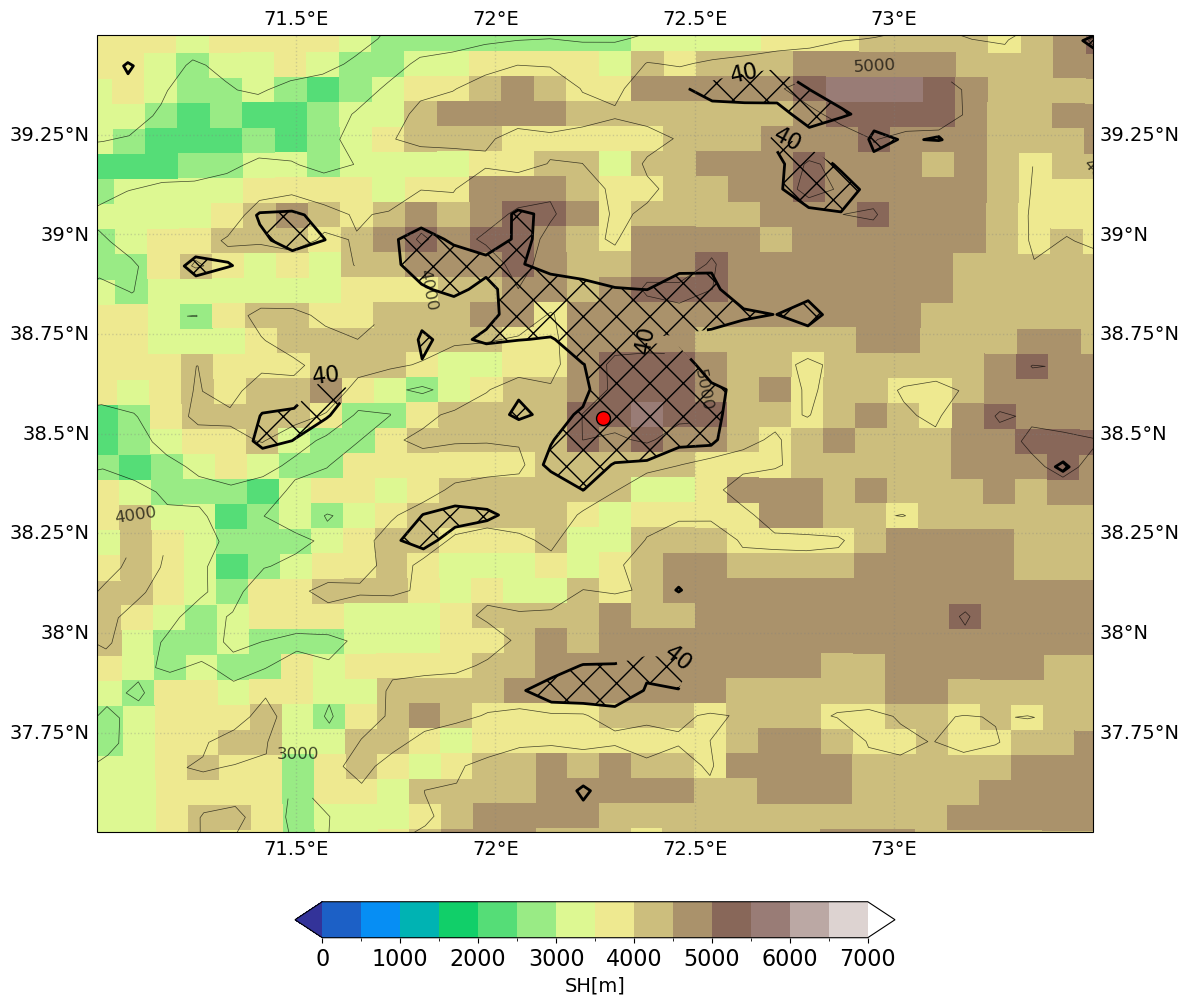

In [10]:
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()

### MAR dataset

In [52]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [53]:
variable='RF'

ds_RF = xr.open_mfdataset(sourceData_1 + "RF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [54]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [55]:
variable='ME' 

ds_ME = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME

In [56]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [57]:
variable='SW' 

# MANQUE FICHIER 2025 SW

#"Surface Water"

ds_SW = xr.open_mfdataset(sourceData_1 + "SW_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SW.isel(SECTOR1_1=0).load()

ds_SW = ds_SW.assign_coords(X=np.round(ds_SW.X.values))
ds_SW = ds_SW.assign_coords(Y=np.round(ds_SW.Y.values))
ds_SW = ds_SW.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SW = ds_SW[:,k:-k,k:-k]

In [58]:
variable='RU' 
# Run Off

ds_RU = xr.open_mfdataset(sourceData_1 + "RU_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RU.isel(SECTOR=0).load()

ds_RU = ds_RU.assign_coords(X=np.round(ds_RU.X.values))
ds_RU = ds_RU.assign_coords(Y=np.round(ds_RU.Y.values))
ds_RU = ds_RU.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RU = ds_RU[:,k:-k,k:-k]

In [59]:
variable='RZ' 
# Refreezing // il faut un monSUM pour RW

ds_RZ = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds_RZ = ds_RZ.assign_coords(X=np.round(ds_RZ.X.values))
ds_RZ = ds_RZ.assign_coords(Y=np.round(ds_RZ.Y.values))
ds_RZ = ds_RZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RZ = ds_RZ[:,k:-k,k:-k]

In [60]:
variable='SU' 
# SMB = SF - ME +RZ - SU - SW

ds_SU = -(ds_SF - (-ds_ME) + ds_RZ - ds_SW - ds_SMB)

In [61]:
variable='SU' 
# SMB = SF + RF - RU - SU - SW

ds_SU_2 = -(ds_SF + ds_RF -ds_RU - ds_SW - ds_SMB)

### HARv2 dataset

In [11]:
# from : https://github.com/msantolariaotin/MAR-RECAP/blob/main/scripts/comparison_pr.crhips_HARv2_MAR_Fedchendko_allseasons.ipynb
# Variable :  pr

fileName7='HARv2_mon_d10km_d_2d_prcp_1980-2023.nc'
ds7_raw0= xr.open_dataset(sourceData_3+'/'+fileName7)['prcp']
ds7_raw=ds7_raw0*24 #mm/h
# Calculate days in each month
days_in_month7= ds7_raw['time'].dt.days_in_month
# Convert to mm/month
ds7= ds7_raw* days_in_month7

def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
       #print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

pr_harv2=xy_sel_dom(ds7.sel(time=slice(str(iyr),str(fyr))),domain)

In [13]:
# Extract pr HARv2 at Jasgulem drilling site
#HARv2 resolution = 10x10km
dist = (pr_harv2.lat - jasg_lat)**2 + (pr_harv2.lon - jasg_lon)**2
j, i = np.unravel_index(dist.argmin(), dist.shape)

pr_harv2_jasg = pr_harv2.isel(south_north=j, west_east=i)

/tmp/ipykernel_513896/3258494667.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  j, i = np.unravel_index(dist.argmin(), dist.shape)


In [16]:
ds_harv2 = xr.open_dataset(sourceData_3 + "HARv2_mon_d10km_d_2d_snowfall_1980-2023.nc")
ds_harv2

<xarray.Dataset> Size: 204MB
Dimensions:      (time: 528, bnds: 2, south_north: 252, west_east: 381)
Coordinates:
  * time         (time) datetime64[ns] 4kB 1980-01-16 1980-02-15 ... 2023-12-16
    lon          (south_north, west_east) float32 384kB ...
    lat          (south_north, west_east) float32 384kB ...
  * west_east    (west_east) float32 2kB -1.675e+06 -1.665e+06 ... 2.125e+06
  * south_north  (south_north) float32 1kB -7.45e+05 -7.35e+05 ... 1.765e+06
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds) datetime64[ns] 8kB ...
    snowfall     (time, south_north, west_east) float32 203MB ...
Attributes: (12/38)
    CDI:                  Climate Data Interface version 2.4.4 (https://mpime...
    Conventions:          CF-1.6
    TITLE:                HAR v2 d10km
    DATA_NOTES:           File generated with the output of successive model ...
    WRF_VERSION:           OUTPUT FROM WRF V4.1 MODEL
    CREATED_BY:           Xun Wang - xun.wang@tu-berlin.de
    ...                   ...
    GRID_Y01:             1765001.0
    GRID_NX:              381
    GRID_NY:              252
    history:              Tue May 06 14:28:51 2025: cdo monmean HARv2_day_d10...
    frequency:            mon
    CDO:                  Climate Data Operators version 2.4.4 (https://mpime...

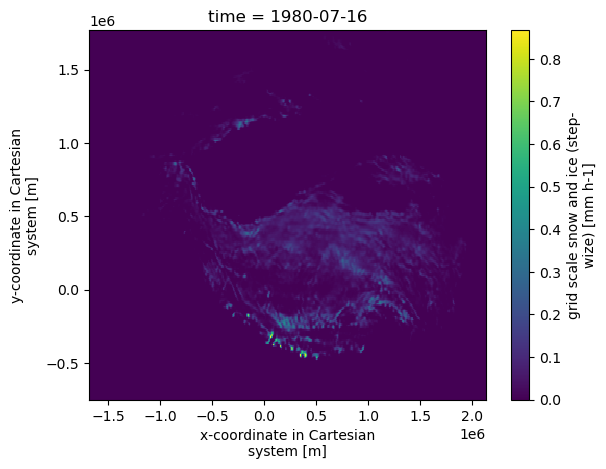

In [17]:
ds_harv2.isel(time=6).isel(bnds=1)['snowfall'].plot()

## MAR et HARv2 au point de Grille JASGULEM FIRN CORE

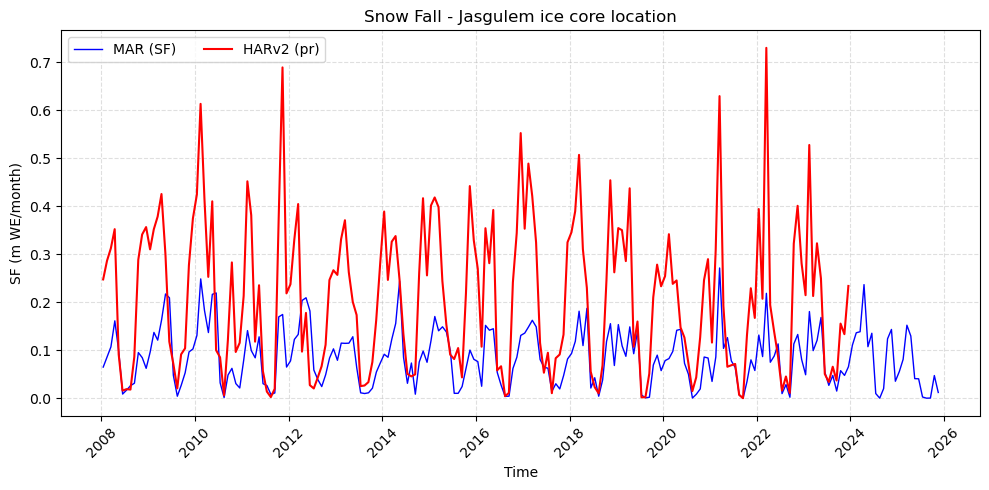

In [20]:
# SF at Jasgulem ice core site

time_start = "2008-01-01"
time_stop = "2025-12-01"

plt.figure(figsize=(10,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice(time_start, time_stop)) / 1000
ds_SF_jasg.plot(label="MAR (SF)", linewidth=1, color="blue")

pr_harv2_jasg_plot= pr_harv2_jasg/1000
pr_harv2_jasg_plot.sel(time=slice(time_start, time_stop)).plot(label = 'HARv2 (pr)', color = 'red')

#Ticks mensuels
ax = plt.gca()
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   # un tick par mois
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format lisible

#Grille verticale alignée sur les ticks
#ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

plt.legend(ncol=3)
plt.title("Snow Fall - Jasgulem ice core location")
plt.ylabel("SF (m WE/month)")

# optionnel : rotation pour lisibilité
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)  # garde aussi la grille horizontale
plt.tight_layout()
plt.show()

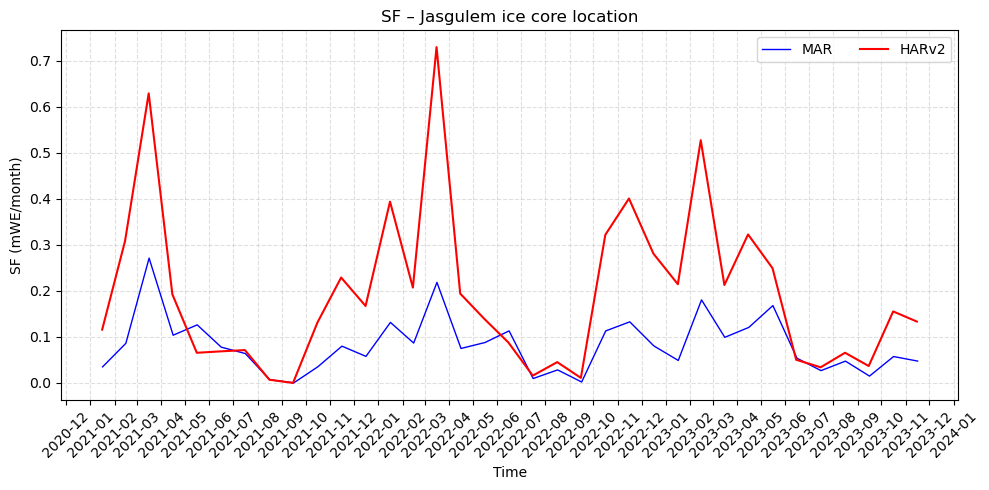

In [77]:
# SF at Jasgulem ice core site

time_start = "2021-01-01"
time_stop = "2023-12-01"

plt.figure(figsize=(10,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice(time_start, time_stop)) / 1000
ds_SF_jasg.plot(label="MAR", linewidth=1, color="blue")

pr_harv2_jasg_plot= pr_harv2_jasg/1000
pr_harv2_jasg_plot.sel(time=slice(time_start, time_stop)).plot(label = 'HARv2', color = 'red')

#Ticks mensuels
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   # un tick par mois
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format lisible

#Grille verticale alignée sur les ticks
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mWE/month)")

# optionnel : rotation pour lisibilité
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)  # garde aussi la grille horizontale
plt.tight_layout()
plt.show()

### Annual cumul of Snow Fall

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


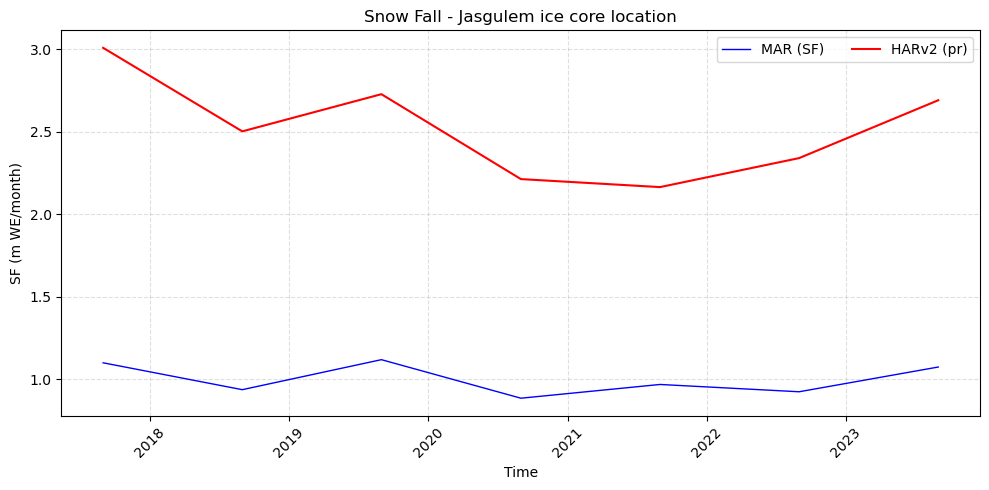

In [25]:
# SF at Jasgulem ice core site

time_start = "2016-09-01"
time_stop = "2023-08-31"

pr_harv2_jasg_annual= pr_harv2_jasg.sel(time=slice(time_start, time_stop)).resample(time="A-AUG").sum()/1000

plt.figure(figsize=(10,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice(time_start, time_stop)).resample(time="A-AUG").sum() / 1000
ds_SF_jasg.plot(label="MAR (SF)", linewidth=1, color="blue")

pr_harv2_jasg_annual= pr_harv2_jasg.sel(time=slice(time_start, time_stop)).resample(time="A-AUG").sum() / 1000
pr_harv2_jasg_annual.plot(label = 'HARv2 (pr)', color = 'red')
#Ticks mensuels
ax = plt.gca()
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   # un tick par mois
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format lisible

#Grille verticale alignée sur les ticks
#ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

plt.legend(ncol=3)
plt.title("Snow Fall - Jasgulem ice core location")
plt.ylabel("SF (m WE/month)")

# optionnel : rotation pour lisibilité
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)  # garde aussi la grille horizontale
plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


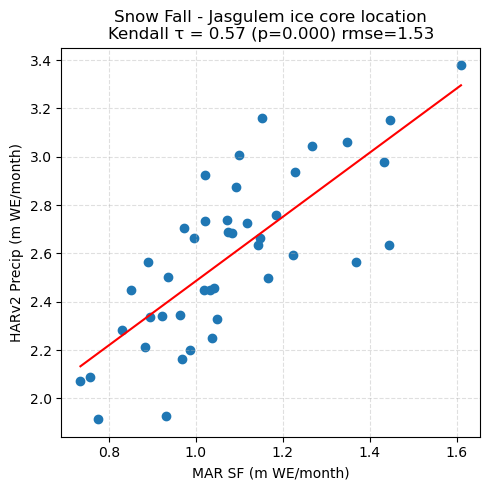

In [105]:
time_start = "1980-09-01"
time_stop = "2023-08-31"


ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice(time_start, time_stop)).resample(time="A-AUG").sum() / 1000
pr_harv2_jasg_annual= pr_harv2_jasg.sel(time=slice(time_start, time_stop)).resample(time="A-AUG").sum()/1000

x = ds_SF_jasg.values
y = pr_harv2_jasg_annual.values

# enlever les NaN
mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# corrélation de Kendall
tau, pval = kendalltau(x_clean, y_clean)

# RMSE
rmse = np.sqrt(np.mean((y - x)**2))

# régression linéaire
coef = np.polyfit(x_clean, y_clean, 1)
poly1d_fn = np.poly1d(coef)

# tri 
idx = np.argsort(x_clean)
x_sorted = x_clean[idx]

# plot
plt.figure(figsize=(5,5))
plt.scatter(x_clean, y_clean)

# ligne de régression
plt.plot(x_sorted, poly1d_fn(x_sorted), color="red")

plt.title(f"Snow Fall - Jasgulem ice core location\nKendall τ = {tau:.2f} (p={pval:.3f}) rmse={rmse:.2f}")
plt.ylabel("HARv2 Precip (m WE/month)")
plt.xlabel("MAR SF (m WE/month)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

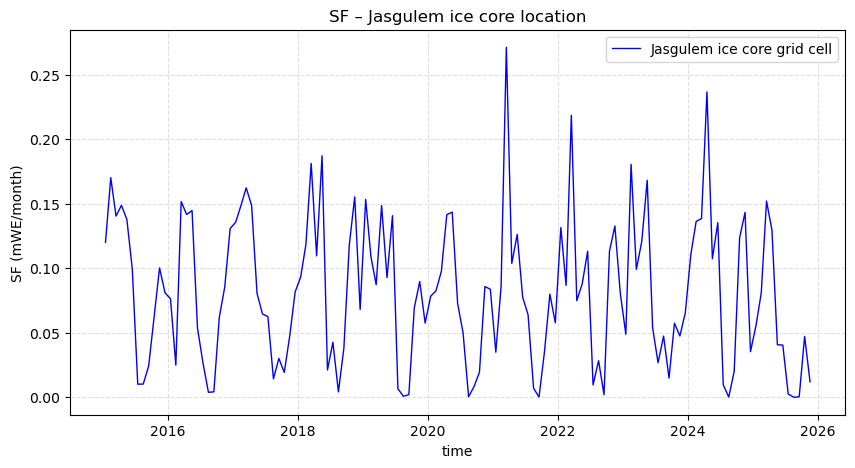

In [27]:
# SF at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_SF_jasg =  ds_SF.isel(Y=iY, X=iX).sel(time=slice("2015-01-01", "2025-12-01"))/1000
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mWE/month)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Comparison with Jasgulem firn drilling dataset

In [35]:
obs_folder = "/bettik/fainx/MAR_HMA/field_data/pamir/"

obs_file = "field_accu_scenarios.txt"
obs_jog_S2 = 'DataFig7_JOG2020_S2.txt'
obs_jog_S1 = 'DataTable2_JOG2020_S1.txt'
obs_2019_pit = '2019_jasgulem_pit_data.txt'

ds_obs_accu =  np.loadtxt(obs_folder+obs_file, delimiter="\t",skiprows=1)
ds_obs_jog_S2 =  np.loadtxt(obs_folder+obs_jog_S2, delimiter="\t",skiprows=1)
ds_obs_jog_S1 =  np.loadtxt(obs_folder+obs_jog_S1, delimiter="\t",skiprows=1)
ds_obs_2019 = np.loadtxt(obs_folder+obs_2019_pit, delimiter="\t",skiprows=1)

In [71]:
# =========================
# 1. DataFrames OBS
# =========================
accu = pd.DataFrame(ds_obs_accu)
jog_S2  = pd.DataFrame(ds_obs_jog_S2)
jog_S1  = pd.DataFrame(ds_obs_jog_S1)
obs_2019 = pd.DataFrame(ds_obs_2019)

# =========================
# 1. DataFrames REANALYSIS
# =========================
pr_harv2_jasg_annual= pd.DataFrame(pr_harv2_jasg.resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2023-08-31"))/1000)
pr_harv2_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(pr_harv2_jasg_annual))
)
pr_harv2_jasg_annual  = pr_harv2_jasg_annual.rename(columns={0: "harv2"})
pr_harv2_jasg_annual = pr_harv2_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# =========================
# 1. DataFrames MODEL
# ========================= SMB
ds_SMB_jasg_annual = pd.DataFrame(ds_SMB.isel(Y=iY, X=iX).resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2025-08-31")) / 1000)
ds_SMB_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(ds_SMB_jasg_annual))
)
ds_SMB_jasg_annual  = ds_SMB_jasg_annual.rename(columns={0: "mar_smb"})
ds_SMB_jasg_annual = ds_SMB_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# ========================= SNOW FALL
ds_SF_jasg_annual = pd.DataFrame(ds_SF.isel(Y=iY, X=iX).resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2025-08-31")) / 1000)
ds_SF_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(ds_SF_jasg_annual))
)
ds_SF_jasg_annual  = ds_SF_jasg_annual.rename(columns={0: "mar_sf"})
ds_SF_jasg_annual = ds_SF_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# ========================= MELT
ds_ME_jasg_annual = pd.DataFrame(ds_ME.isel(Y=iY, X=iX).resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2025-08-31")) / 1000)
ds_ME_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(ds_SMB_jasg_annual))
)
ds_ME_jasg_annual  = ds_ME_jasg_annual.rename(columns={0: "mar_me"})
ds_ME_jasg_annual = ds_ME_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# =========================
# 2. Renommer colonne année
# =========================
accu = accu.rename(columns={0: "year"})
jog_S2  = jog_S2.rename(columns={0: "year"})
jog_S1  = jog_S1.rename(columns={0: "year"})
obs_2019  = obs_2019.rename(columns={0: "year"})

# =========================
# 3. SUPPRESSION des colonnes 1 à 9 de accu: ce sont les depths
# =========================
accu = accu.drop(columns=list(range(2, 10)))
accu = accu.drop(columns=list(range(11, 19)))

# =========================
# 4. Renomer les colonnes 
# =========================
accu = accu.rename(columns={accu.columns[1]: "depth_Fed_2025"})
accu = accu.rename(columns={accu.columns[2]: "accu_Fed_2025"})

#jog.columns  = ["year"] + [f"jog_{i}" for i in range(1, jog.shape[1])]
jog_S2 = jog_S2.rename(columns={jog_S2.columns[1]: "firn_model_2015"})
jog_S2 = jog_S2.rename(columns={jog_S2.columns[2]: "gpr_s2_2015"})
jog_S2 = jog_S2.rename(columns={jog_S2.columns[3]: "harv2_Lambrecht"})
jog_S2 = jog_S2.rename(columns={jog_S2.columns[4]: "S2"})

jog_S1 = jog_S1.rename(columns={jog_S1.columns[1]: "S1"})

obs_2019 = obs_2019.rename(columns={obs_2019.columns[1]: "pit_2019"})

# =========================
# 5. Nettoyage années invalides
# =========================
accu = accu[accu["year"].notna()]
jog_S2  = jog_S2[jog_S2["year"].notna()]
jog_S1  = jog_S1[jog_S1["year"].notna()]
obs_2019  = obs_2019[obs_2019["year"].notna()]
ds_SMB_jasg_annual  = ds_SMB_jasg_annual[ds_SMB_jasg_annual["year"].notna()]

# =========================
# 6. Merge sur year
# =========================
merged = pd.merge(accu, jog_S2, on="year", how="outer")
merged = pd.merge(merged, jog_S1, on="year", how="outer")
merged = pd.merge(merged, obs_2019, on="year", how="outer")
merged = pd.merge(merged, pr_harv2_jasg_annual, on="year", how="outer")
merged = pd.merge(merged, ds_SMB_jasg_annual, on="year", how="outer")
merged = pd.merge(merged, ds_SF_jasg_annual, on="year", how="outer")
merged = pd.merge(merged, ds_ME_jasg_annual, on="year", how="outer")


# =========================
# 7. Tri chronologique
# =========================
merged = merged.sort_values("year", ascending=False).reset_index(drop=True)

# =========================
# 8. garder DataFrame 
# =========================
ds = merged  
ds = ds.dropna(how="all")

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


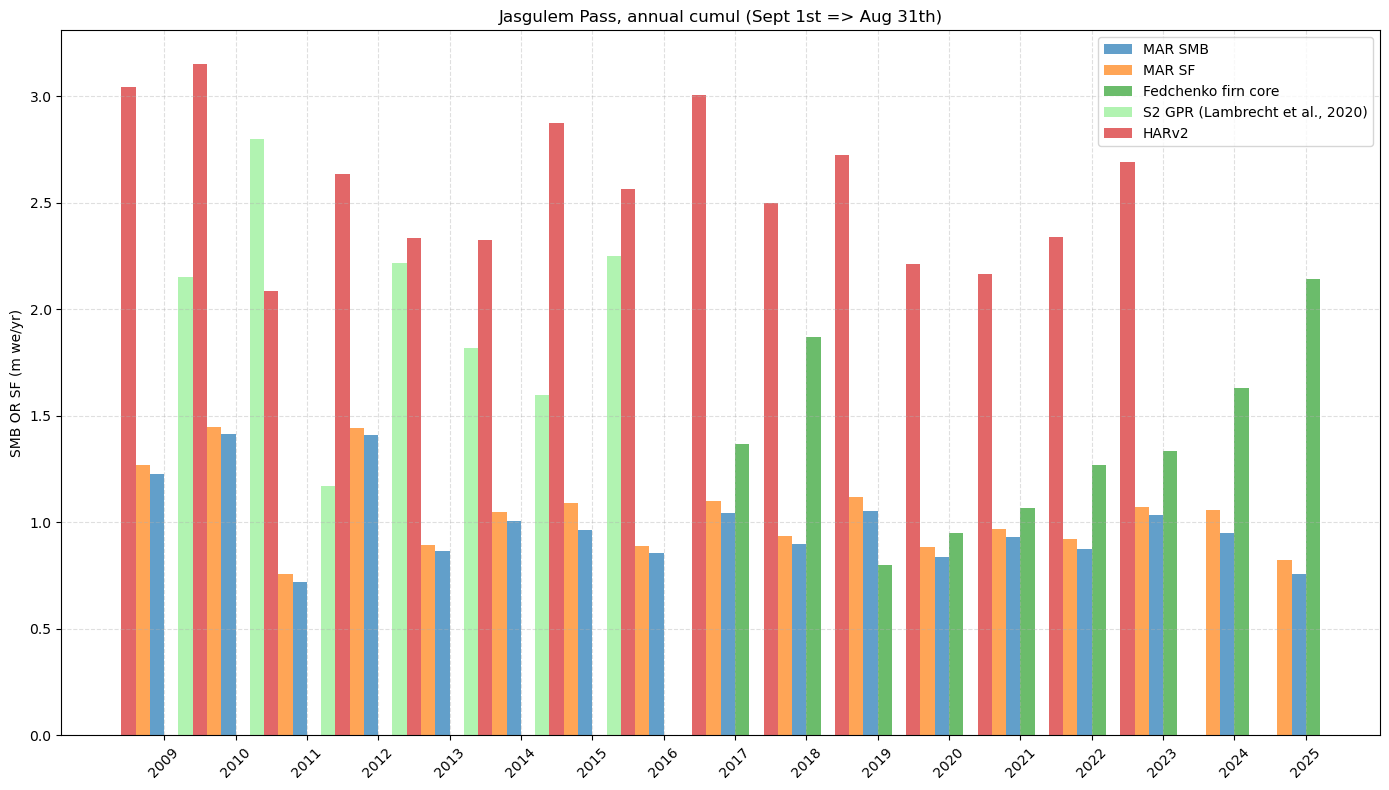

In [70]:
df = ds.copy()
df = df.sort_values("year")

x = np.arange(len(df))
width = 0.2

plt.figure(figsize=(14, 8))

# MAR SMB and SF
plt.bar(x - 0.5*width, df["mar_smb"], width, label="MAR SMB", alpha=0.7)
plt.bar(x - 1.5*width, df["mar_sf"], width, label="MAR SF", alpha=0.7)

# Jasgulem obs
plt.bar(x + 0.5*width, df["accu_Fed_2025"], width, label="Fedchenko firn core", alpha=0.7)
plt.bar(x + 1.5*width, df["gpr_s2_2015"], width, label="S2 GPR (Lambrecht et al., 2020)", alpha=0.7, color='lightgreen')
# plt.bar(x + 2.5*width, df["pit_2019"], width, label="2019 pit", alpha=0.7)
# plt.bar(x + 1.5*width, df["S2"], width, label="S2 pit", alpha=0.7)

# HARv2
plt.bar(x - 2.5*width, df["harv2"], width, label="HARv2", alpha=0.7)


labels = df["year"].astype(int).astype(str)
plt.xticks(x, labels, rotation=45)


plt.ylabel("SMB OR SF (m we/yr)")
plt.title("Jasgulem Pass, annual cumul (Sept 1st => Aug 31th)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [73]:
ds

,year,depth_Fed_2025,accu_Fed_2025,firn_model_2015,gpr_s2_2015,harv2_Lambrecht,S2,S1,pit_2019,harv2,mar_smb,mar_sf,mar_me
0,2025.0,0.0,2.141993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.756256,0.823760,-0.529248
1,2024.0,453.0,1.630206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.947804,1.059190,-0.713462
2,2023.0,771.0,1.335000,NaN,NaN,NaN,NaN,NaN,NaN,2.690328,1.035123,1.073057,-0.287154
3,2022.0,972.0,1.269131,NaN,NaN,NaN,NaN,NaN,NaN,2.339624,0.875122,0.923108,-0.333972
4,2021.0,1178.0,1.068728,NaN,NaN,NaN,NaN,NaN,NaN,2.163827,0.933105,0.967340,-0.183595
5,2020.0,1366.0,0.947912,NaN,NaN,NaN,NaN,NaN,NaN,2.212338,0.836139,0.884065,-0.112785
6,2019.0,1537.0,0.799795,NaN,NaN,NaN,1.41,NaN,0.6,2.727126,1.054667,1.117668,-0.588300
7,2018.0,1673.0,1.871855,NaN,NaN,NaN,NaN,NaN,NaN,2.501698,0.896610,0.935760,-0.405200
8,2017.0,1953.0,1.366651,NaN,NaN,NaN,NaN,NaN,NaN,3.007985,1.045279,1.098650,-0.527983
9,2016.0,2185.0,NaN,NaN,NaN,NaN,NaN,1.301,NaN,2.565352,0.853577,0.890981,-0.180882


### HARv2 vs 2025 Jasgulem firn core data

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


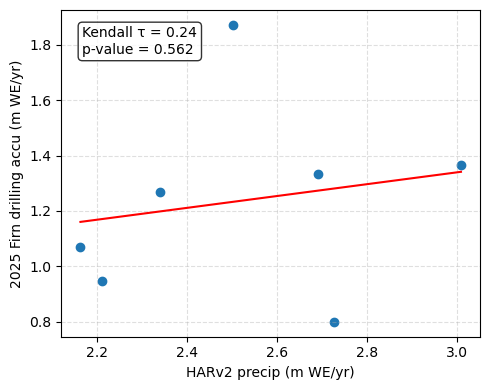

In [145]:
# Rank correlation Jasgulem OBS 2025 vs HARv2

obs = ds_obs_accu[2:-2,10]# Scenario 1,  17/18 - 22/23
obs = obs[::-1] 

# obs = ds['accu_Fed_2025']
harv= pr_harv2_jasg.sel(time=slice("2016-09-01", "2023-08-31")).resample(time="A-AUG").sum() / 1000

# -------------------------
# Kendall rank correlation
# -------------------------
tau, pval = kendalltau(harv, obs)

# -------------------------
# RMSE
# -------------------------
rmse = np.sqrt(np.mean((harv-obs)**2))

# -------------------------
# regression line
# -------------------------
coef = np.polyfit(harv, obs, 1)
fit = np.poly1d(coef)
x = np.sort(harv)

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(5,4))
plt.scatter(harv, obs)
plt.plot(x, fit(x), color="red")

plt.ylabel("2025 Firn drilling accu (m WE/yr)")
plt.xlabel("HARv2 precip (m WE/yr)")

# annotation box
text = f"Kendall τ = {tau:.2f}\np-value = {pval:.3f}"

plt.text(
    0.05, 0.95, text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### HARv2 vs 2015 Jasgulem firn core data

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


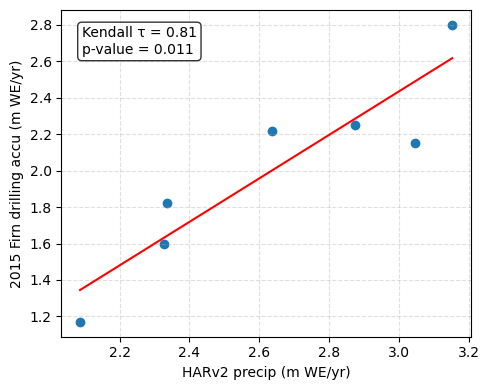

In [136]:
# Rank correlation Jasgulem OBS 2015 vs HARv2

obs = ds_obs_jog_S2[4:,2] # Scenario 2008/09 - 2014/5
obs = obs[::-1] 

# obs = ds['accu_Fed_2025']
harv= pr_harv2_jasg.sel(time=slice("2008-09-01", "2015-08-31")).resample(time="A-AUG").sum() / 1000

# -------------------------
# Kendall rank correlation
# -------------------------
tau, pval = kendalltau(harv, obs)

# -------------------------
# RMSE
# -------------------------
rmse = np.sqrt(np.mean((harv-obs)**2))

# -------------------------
# regression line
# -------------------------
coef = np.polyfit(harv, obs, 1)
fit = np.poly1d(coef)
x = np.sort(harv)

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(5,4))
plt.scatter(harv, obs)
plt.plot(x, fit(x), color="red")

plt.ylabel("2015 Firn drilling accu (m WE/yr)")
plt.xlabel("HARv2 precip (m WE/yr)")

# annotation box
text = f"Kendall τ = {tau:.2f}\np-value = {pval:.3f}"

plt.text(
    0.05, 0.95, text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


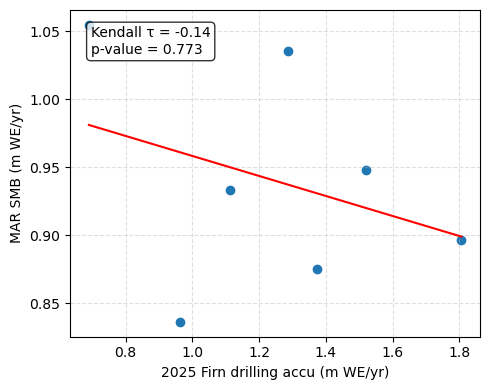

In [46]:
# Rank correlation OBS vs MAR

obs = ds_obs_accu[1:-3,11] # Scenario 2
obs = obs[::-1] 
mar = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("2017-09-01", "2024-08-31")).resample(time="A-AUG").sum() / 1000


# -------------------------
# Kendall rank correlation
# -------------------------
tau, pval = kendalltau(obs, mar)

# -------------------------
# RMSE
# -------------------------
rmse = np.sqrt(np.mean((obs - mar)**2))

# -------------------------
# regression line
# -------------------------
coef = np.polyfit(obs, mar, 1)
fit = np.poly1d(coef)
x = np.sort(obs)

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(5,4))
plt.scatter(obs, mar)
plt.plot(x, fit(x), color="red")

plt.xlabel("2025 Firn drilling accu (m WE/yr)")
plt.ylabel("MAR SMB (m WE/yr)")

# annotation box
text = f"Kendall τ = {tau:.2f}\np-value = {pval:.3f}"

plt.text(
    0.05, 0.95, text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()